# Construction mechanisms: pretrained variants against the baseline (axis-200-900)

Which element of the synthetic-data construction causes a difference: permutations versus single bins, staged versus joint schedule, the overlap quota and the rare quota? Stage shown: **pretrained**, i.e. the model right after the synthetic phases, evaluated on real data without any real-data training (0 real epochs); its head was trained with BCE on complete synthetic targets.

## Introduction

The thesis tested in parts 2-6 is that synthetic pretraining improves on the model trained on real data only.
Every table therefore contains the **real-only baseline** of the same axis (10 real epochs from the same
initialization) and every comparison is a **paired difference to that baseline**.

The ten pretraining variants differ only in the synthetic data seen before real data (campaign methodology,
`pretraining_campaign_methodology.md`):

| Variant | Synthetic phases | Construction |
| --- | --- | --- |
| P0 single bins | 1 x 10 epochs | ten spectra per axis bin; annotated bins carry their labels, blank bins are known negatives |
| P1 permutations | 1 x 10 epochs | component-token bag (30 per class and per blank bin) packed into mixed spectra |
| P2 joint / staged | 1 x 10 / 2 x 10 epochs | P0 and P1 rows shuffled together / P0 first, then P1 |
| P3 joint / staged | as P2 | P2 + overlap quota (30 extra tokens per class that shares a bin with another class in a training pixel) |
| P4 joint / staged | as P2 | P2 + rare quota (30 extra tokens per class of the least-annotated quarter) |
| P5 joint / staged | as P2 | P2 + both quotas |

Every variant yields three models along one lineage (stages): `pretrained`, `frozen_head` and `unfrozen_head`.
The staged schedules train twice as many synthetic epochs as the joint ones, so schedule and budget are
confounded (methodology, "Pretraining ablation").

### Assumptions

* **Pairing.** Repetition $r$ uses one initialization seed for the baseline and for every variant and stage
  (verified for all 310 models in the campaign-plan verification). The difference between a variant and the
  baseline of the same repetition removes the initialization effect; the five repetitions are the independent
  units. Pixels are not independent units and never enter a test as such.
* **Data.** Every model is evaluated on identical pixels: the same `train`, `test`, `test_extended` and
  `heldout_image` populations as in part 1, decoded once in the shared cache.
* **Objectives.** Synthetic phases: Masserstein (1.0) + BCE (0.2) on complete synthetic targets. Real phases
  (baseline and both fine-tuning stages): Masserstein (1.0) + VPU (0.2) + contractive (2e-3) + InfoNCE (1e-3,
  multilabel-Jaccard negatives, added by mistake and kept because every model used it).
* **Threshold metrics.** Precision, recall and F1 use $\hat Y \ge 0.5$, as in part 1. A head whose
  probabilities never reach 0.5 on real data has F1 = 0 although its ranking may still carry information;
  average precision is threshold free and is the primary head metric.
* **Uncertainty.** With five repetitions the Student-t interval has 4 degrees of freedom
  ($t_{0.975,4} = 2.78$); an interval that excludes zero is a strong statement, one that includes zero is not
  evidence of no effect.

### Notation

* $b_r$, $v_r$: value of a metric for the baseline and for a variant (at one stage) in repetition $r$.
* $s_m \in \{-1, +1\}$: direction of metric $m$; $-1$ for lower-is-better metrics (Masserstein $W_1$,
  spectral angle, MSE, Hamming loss, window contribution and within-window $W_1$, absolute mass imbalance, ECE,
  Brier score, true-label rank, false-positive rate and lift, losses), $+1$ otherwise.
* **Improvement** $\Delta_r = s_m (v_r - b_r)$: positive is always better than the baseline.
  **Relative improvement** $\Delta_r / |b_r|$.
* Summary over repetitions: mean $\bar\Delta$, SD $s$, interval $\bar\Delta \pm t_{0.975, n-1}\, s / \sqrt{n}$,
  and the numbers of repetitions with $\Delta_r > 0$ (`+k`) and $\Delta_r < 0$ (`-m`).
* Evaluations: `test` (withheld pixels of training images), `test_combined` (test + rare-class extension, the
  main per-class estimate), `heldout_image` (three images never seen; pooled), `heldout_image_per_image` (mean of
  the per-image values; pooled held-out values understate the ranking because annotations are incomplete across
  images, part 1_08).
* $W_1$: exact one-dimensional Wasserstein-1 distance between TIC-normalized input and reconstruction (m/z
  units); $u$: canonical latent code (LayerNorm affine removed).

## Configuration

In [1]:
import logging
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# Library modules log INFO to stdout; warnings stay visible, progress messages do not.
logging.disable(logging.INFO)
current_path = Path.cwd().resolve()
repository_root = next(path for path in (current_path, *current_path.parents) if (path / "pyproject.toml").is_file())
os.chdir(repository_root)

from msi_autoencoder_wrapper.analysis.autoencoder.experiments import pretraining_campaign as campaign
from msi_autoencoder_wrapper.analysis.autoencoder.experiments.pretraining_campaign_precompute import (
    load_metadata, load_table, run_command,
)
from msi_autoencoder_wrapper.analysis.precompute.notebook_inputs import load_model_catalog, load_visualization_theme
from msi_autoencoder_wrapper.visualization import pretraining as figures

SETTINGS_PATH = Path("assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/analysis_settings.yaml")
ANALYSIS = "stage_mechanisms"
AXIS = "axis-200-900"
STAGE = "pretrained"

settings = campaign.load_settings(SETTINGS_PATH)
theme = load_visualization_theme(settings).with_overrides(figure_dpi=100)
catalog = load_model_catalog(settings)
metadata = load_metadata(settings, ANALYSIS, AXIS, STAGE)
pd.set_option("display.precision", 4)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 80)


def table(name: str) -> pd.DataFrame:
    """Load one canonical table written for this notebook by the precompute."""
    return load_table(settings, ANALYSIS, name, AXIS, STAGE)


def mean_sd(frame: pd.DataFrame, keys: list, columns: list) -> pd.DataFrame:
    """Mean and SD over repetitions of the given columns (presentation helper)."""
    long = frame.melt(id_vars=keys, value_vars=columns, var_name="quantity", value_name="value")
    return long.groupby([*keys, "quantity"]).value.agg(["mean", "std"]).unstack("quantity")


POPULATION_COLORS = {name: figures.population_color(name, theme) for name in figures.POPULATION_ORDER}
print("Analysis:", ANALYSIS, "| axis:", AXIS, "| stage:", STAGE, "| models:", metadata["models"] if isinstance(metadata["models"], int) else len(metadata["models"]))
print("Cache keys:", metadata["cache_keys"])

BASELINE = "baseline"
VARIANTS = list(settings["variants"])
VARIANT_LABELS = {BASELINE: "real-only baseline", **{name: value["label"] for name, value in settings["variants"].items()}}
## The baseline keeps its catalog colour (the dark theme baseline colour is reserved for reference lines)
BASELINE_COLOR = next(value["visualization"]["color"] for value in settings["models"].values()
                      if value.get("select", {}).get("role") == settings["baseline_role"])
VARIANT_COLORS = {BASELINE: BASELINE_COLOR, **{name: value["color"] for name, value in settings["variants"].items()}}
STAGES = list(settings["stages"])
STAGE_LABELS = {"real_only": "real-only baseline", **{name: value["label"] for name, value in settings["stages"].items()}}
KEY_METRICS = settings["comparison"]["key_metrics"]
AXES = list(settings["axes"])
AXIS_LABELS = {name: value["label"] for name, value in settings["axes"].items()}
SHORT = {"masserstein": "W1", "spectral_angle": "spectral angle", "average_precision": "macro AP",
         "micro_average_precision": "micro AP", "f1": "macro F1 at 0.5"}
EVALUATION_NAMES = {**figures.DISPLAY_NAMES, "heldout_image_per_image": "held-out, per image"}


def key_panels(reconstruction=("test", "heldout_image"), prediction=("test_combined", "heldout_image_per_image")):
    """Forest-plot panels of the key metrics: (title, row selector)."""
    panels = []
    for spec in KEY_METRICS:
        for evaluation in (reconstruction if spec["family"] == "reconstruction" else prediction):
            selector = {"family": spec["family"], "metric": spec["metric"], "evaluation": evaluation,
                        "ranking": spec.get("ranking", "none")}
            panels.append((f"{SHORT.get(spec['metric'], spec['metric'])}, {EVALUATION_NAMES.get(evaluation, evaluation)}", selector))
    return panels


def interval(frame, digits=3):
    """'mean [ci_low, ci_high] (+k/-m)' strings of a summary table."""
    form = "{:." + str(digits) + "g}"
    return (frame["mean"].map(form.format) + " [" + frame.ci_low.map(form.format) + ", "
            + frame.ci_high.map(form.format) + "] (+" + frame.positive.astype(int).astype(str) + "/-"
            + frame.negative.astype(int).astype(str) + ")")

from msi_autoencoder_wrapper.analysis.autoencoder.experiments.pretraining_campaign_comparison import summarize

ORDER = [BASELINE, *VARIANTS]
EVALUATIONS = ['test', 'test_combined', 'heldout_image', 'heldout_image_per_image']

contrasts = table('contrasts')
contrast_summary = table('contrast_summary')
factorial = table('factorial')
factorial_summary = table('factorial_summary')
CONTRASTS = list(settings['comparison']['contrasts'])
CONTRAST_LABELS = {name: ' + '.join(VARIANT_LABELS[v] for v in spec['plus']) + '  -  ' + ' + '.join(VARIANT_LABELS[v] for v in spec['minus'])
                   for name, spec in settings['comparison']['contrasts'].items()}
CONTRAST_COLORS = {name: VARIANT_COLORS[spec['plus'][0]] for name, spec in settings['comparison']['contrasts'].items()}
TERMS = ['schedule', 'overlap', 'rare', 'schedule:overlap', 'schedule:rare', 'overlap:rare']

Analysis: stage_mechanisms | axis: axis-200-900 | stage: pretrained | models: 55
Cache keys: {'plan': 'f34a92a8f6f7833f', 'populations': '513690bdd78a83ce', 'synthetic_reference': '6ba5bc1e0839ba0e', 'inference': '0243c1efb93b9c4c'}


## Producing the tables this notebook reads

### Methodology

#### Implementation

`stage_mechanisms` builds the key-metric table of the variants of this stage and evaluates the configured
contrasts and the $2 \times 2 \times 2$ factorial design (schedule x overlap x rare over P2-P5) per
repetition.

The command below is generated by the precompute entry point itself; if a table is missing, `load_table` raises with the same command.

In [2]:
print(run_command(settings, ANALYSIS))

nohup uv run --extra cu118 python -m msi_autoencoder_wrapper.analysis.precompute --settings /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/analysis_settings.yaml --analysis stage_mechanisms > /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/shared_precompute.log 2>&1 &


### Remarks

### Notes

## Absolute results of every variant and of the real-only baseline

### Methodology

#### Theoretical

The paired improvements below answer *whether* a variant differs from the baseline; this section shows *what
every model reaches*: the absolute value of every key metric for the real-only baseline and for every variant,
so that a difference can be read against the level at which it happens.

#### Implementation

`model_values` holds one value per model, metric and evaluation population (repetitions of a variant = its five models).

#### Figure descriptions

        First figure: one panel per key metric and evaluation; x = baseline and variants, violin and points = the five
        repetitions, bar = mean. Tables: the reconstruction metrics on test and held-out pixels, then the complete
        prediction metric set (annotation retrieval, training-supported classes) per evaluation population.

Colours: in the figures the baseline is grey (its mean is the dashed line) and every other group is green when its
mean is better than the baseline mean and red when it is worse. In the tables every cell is mean +/- SD over the
repetitions; green / red cells are better / worse than the baseline cell of the same column (stronger colour = larger
difference within the column), the black frame marks the three best rows of the column and the grey bold row is the
real-only baseline.

In [3]:
LOWER_IS_BETTER = {'masserstein', 'spectral_angle', 'mse', 'hamming_loss', 'expected_calibration_error', 'brier_score',
                   'within', 'contribution', 'absolute_mass_imbalance', 'bic'}
METRIC_ORDER = ['average_precision', 'micro_average_precision', 'roc_auc', 'micro_roc_auc', 'ap_above_prevalence',
                'precision', 'recall', 'f1', 'micro_precision', 'micro_recall', 'micro_f1', 'micro_prevalence',
                'hamming_loss']
ABS_ORDER = [BASELINE, *VARIANTS]
LABELS_ABS = {**VARIANT_LABELS, **{name: VARIANT_LABELS.get(name, name) for name in ABS_ORDER}}


def better(metric):
    """Direction of a metric: 'lower' or 'higher' is better."""
    return 'lower' if metric in LOWER_IS_BETTER else 'higher'

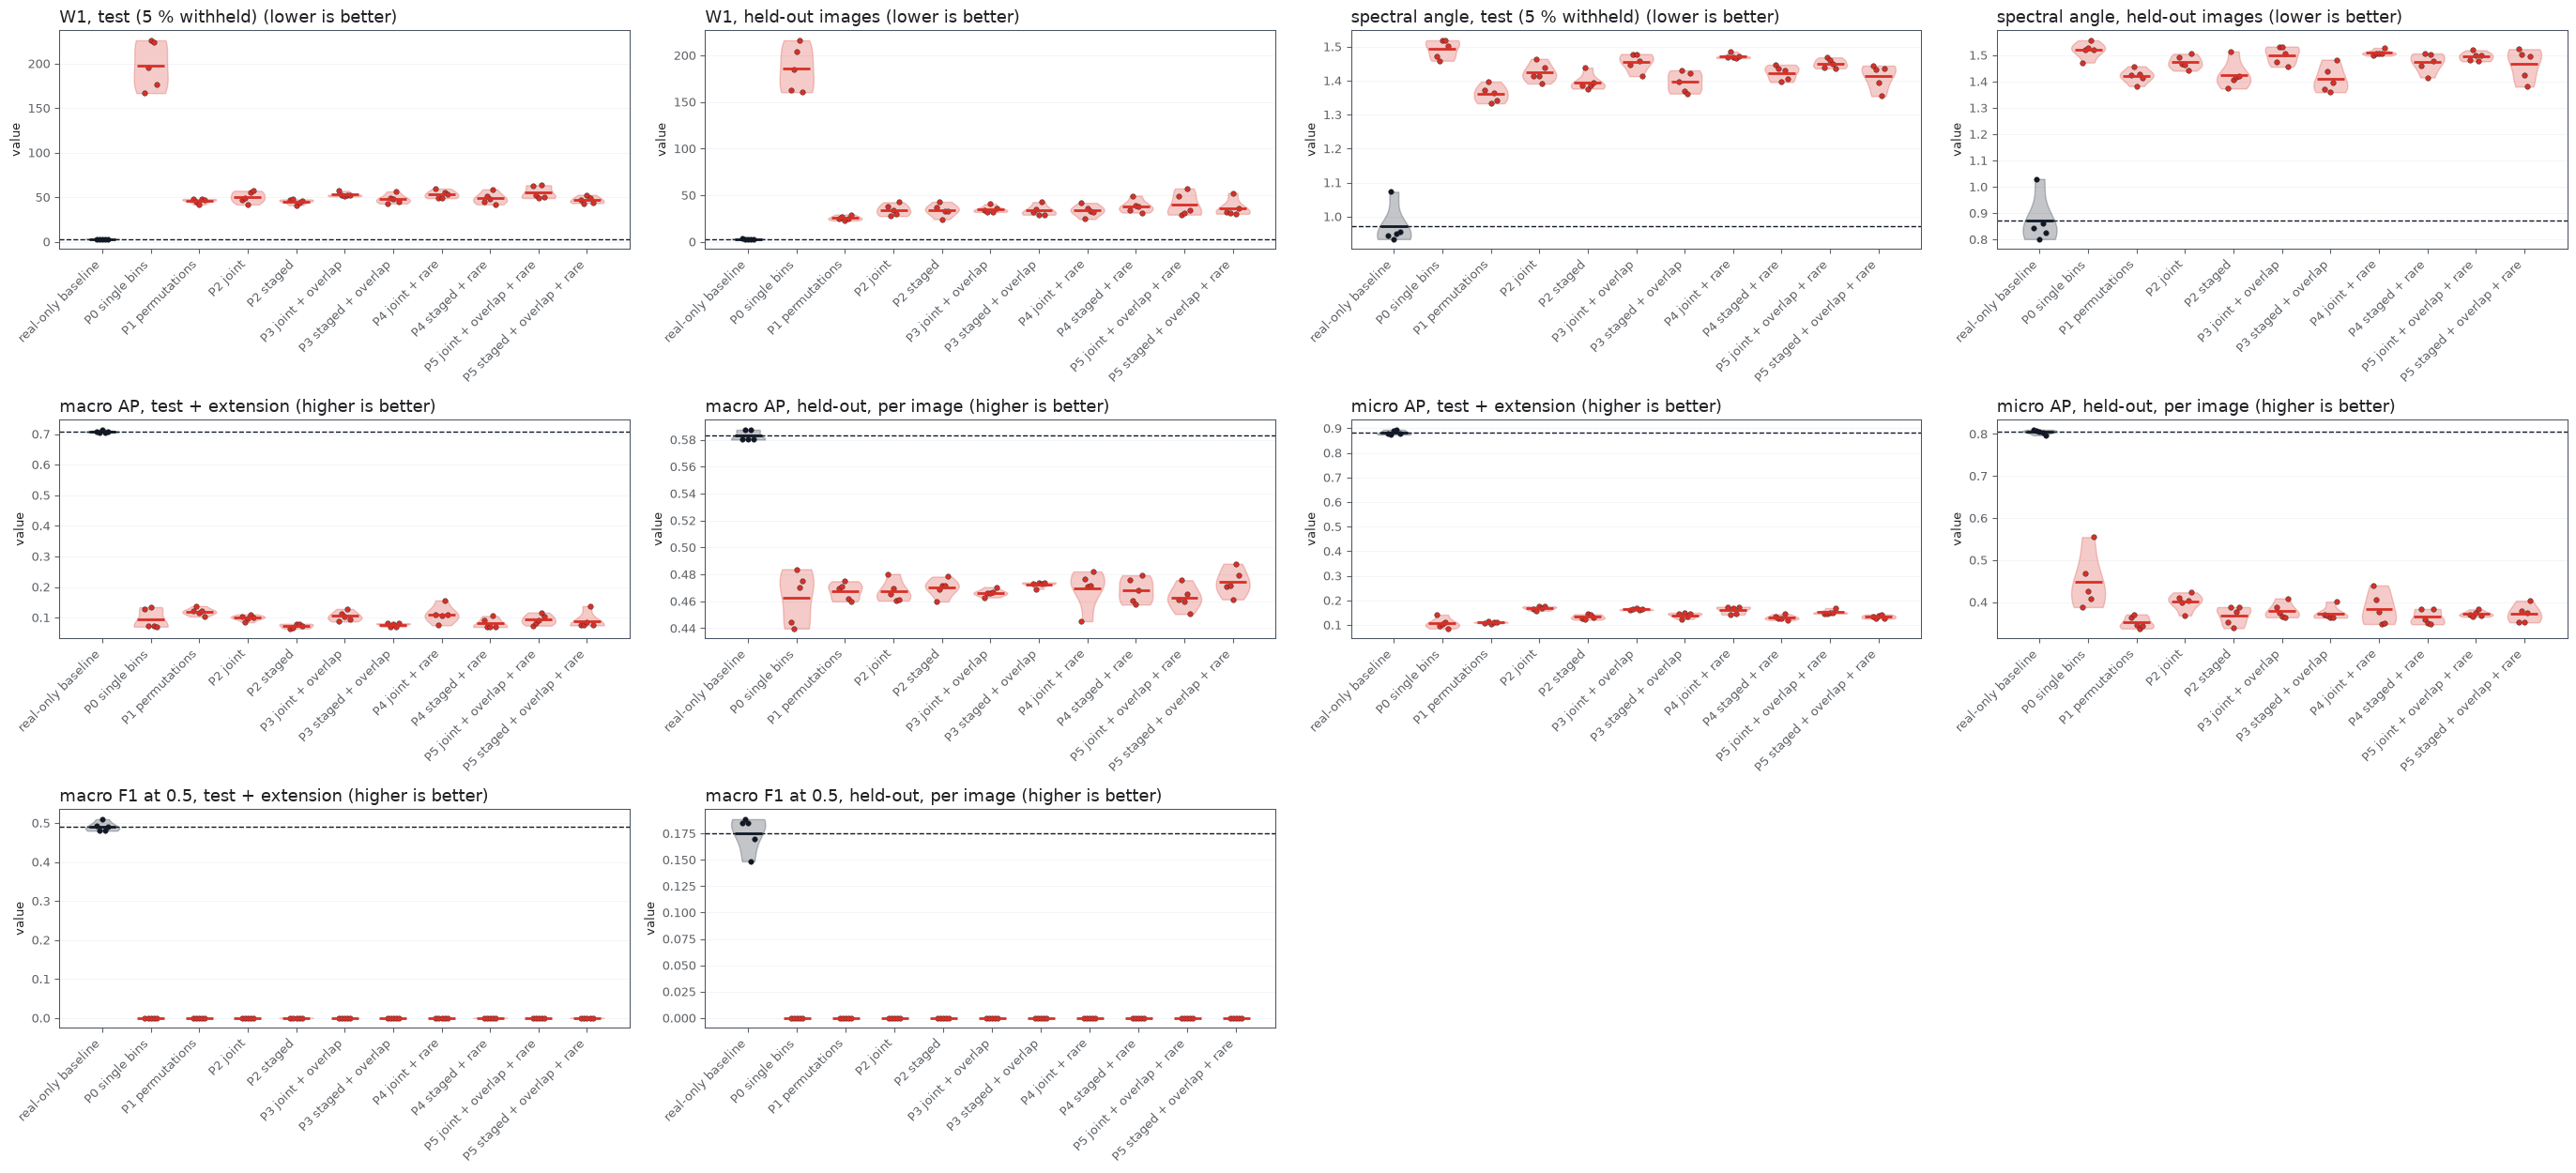

In [4]:
metrics_abs = table('model_values')

panels = []
for spec in KEY_METRICS:
    evaluations = ['test', 'heldout_image'] if spec['family'] == 'reconstruction' else ['test_combined', 'heldout_image_per_image']
    for evaluation in evaluations:
        panels.append((f"{SHORT[spec['metric']]}, {EVALUATION_NAMES.get(evaluation, evaluation)}",
                       {'family': spec['family'], 'metric': spec['metric'], 'evaluation': evaluation,
                        'ranking': spec.get('ranking', 'none')}, better(spec['metric'])))
figures.metric_panels(metrics_abs, panels=panels, group='variant', order=ABS_ORDER, labels=LABELS_ABS, baseline=BASELINE, columns=4, theme=theme);

In [5]:
recon = metrics_abs[(metrics_abs.family == 'reconstruction') & metrics_abs.evaluation.isin(['test', 'heldout_image'])]
recon = recon.assign(column=recon.metric + ' | ' + recon.evaluation)
columns = [f'{metric} | {evaluation}' for evaluation in ('test', 'heldout_image') for metric in ('masserstein', 'spectral_angle', 'cosine_similarity', 'mse')]
display(figures.comparison_table(recon, index='variant', columns='column', baseline=BASELINE, order=ABS_ORDER, column_order=columns,
                                 direction={column: better(column.split(' | ')[0]) for column in columns}))
prediction_abs = metrics_abs[(metrics_abs.family == 'prediction') & (metrics_abs.ranking == 'annotation_retrieval')]
for evaluation in ('test_combined', 'heldout_image', 'heldout_image_per_image'):
    rows = prediction_abs[prediction_abs.evaluation == evaluation]
    if rows.empty:
        continue
    print(EVALUATION_NAMES.get(evaluation, evaluation))
    display(figures.comparison_table(rows, index='variant', columns='metric', baseline=BASELINE, order=ABS_ORDER,
                                     column_order=METRIC_ORDER, direction={metric: better(metric) for metric in rows.metric.unique()}))

column,masserstein | test,spectral_angle | test,masserstein | heldout_image,spectral_angle | heldout_image
variant,,,,
baseline,3.117 +/- 0.109,0.972 +/- 0.057,3.076 +/- 0.143,0.873 +/- 0.091
P0_single,197.775 +/- 26.938,1.494 +/- 0.027,185.632 +/- 24.787,1.520 +/- 0.031
P1_permutation,46.056 +/- 2.657,1.362 +/- 0.026,25.799 +/- 2.581,1.422 +/- 0.027
P2_joint_base,50.160 +/- 6.343,1.424 +/- 0.028,34.328 +/- 5.988,1.474 +/- 0.026
P2_staged_base,45.214 +/- 2.680,1.396 +/- 0.025,34.137 +/- 6.829,1.426 +/- 0.053
P3_joint_overlap,52.983 +/- 2.360,1.455 +/- 0.027,34.893 +/- 3.518,1.500 +/- 0.034
P3_staged_overlap,48.194 +/- 5.284,1.396 +/- 0.030,33.563 +/- 5.702,1.410 +/- 0.051
P4_joint_rare,53.377 +/- 4.432,1.472 +/- 0.008,33.484 +/- 6.357,1.510 +/- 0.011
P4_staged_rare,48.983 +/- 6.597,1.423 +/- 0.021,38.207 +/- 6.986,1.473 +/- 0.037


test + extension


metric,average_precision,micro_average_precision,f1
variant,,,
baseline,0.709 +/- 0.003,0.883 +/- 0.009,0.491 +/- 0.012
P0_single,0.096 +/- 0.032,0.107 +/- 0.021,0.000 +/- 0.000
P1_permutation,0.120 +/- 0.012,0.110 +/- 0.004,0.000 +/- 0.000
P2_joint_base,0.099 +/- 0.009,0.169 +/- 0.008,0.000 +/- 0.000
P2_staged_base,0.073 +/- 0.007,0.133 +/- 0.010,0.000 +/- 0.000
P3_joint_overlap,0.105 +/- 0.016,0.164 +/- 0.003,0.000 +/- 0.000
P3_staged_overlap,0.076 +/- 0.006,0.140 +/- 0.011,0.000 +/- 0.000
P4_joint_rare,0.111 +/- 0.029,0.161 +/- 0.015,0.000 +/- 0.000
P4_staged_rare,0.081 +/- 0.016,0.131 +/- 0.009,0.000 +/- 0.000


held-out images


metric,average_precision,micro_average_precision,f1
variant,,,
baseline,0.356 +/- 0.007,0.592 +/- 0.010,0.140 +/- 0.015
P0_single,0.262 +/- 0.023,0.244 +/- 0.031,0.000 +/- 0.000
P1_permutation,0.254 +/- 0.001,0.197 +/- 0.010,0.000 +/- 0.000
P2_joint_base,0.260 +/- 0.014,0.229 +/- 0.015,0.000 +/- 0.000
P2_staged_base,0.259 +/- 0.008,0.209 +/- 0.016,0.000 +/- 0.000
P3_joint_overlap,0.259 +/- 0.009,0.219 +/- 0.017,0.000 +/- 0.000
P3_staged_overlap,0.266 +/- 0.016,0.211 +/- 0.011,0.000 +/- 0.000
P4_joint_rare,0.258 +/- 0.009,0.220 +/- 0.017,0.000 +/- 0.000
P4_staged_rare,0.275 +/- 0.027,0.206 +/- 0.012,0.000 +/- 0.000


held-out, per image


metric,average_precision,micro_average_precision,f1
variant,,,
baseline,0.583 +/- 0.004,0.805 +/- 0.005,0.175 +/- 0.017
P0_single,0.463 +/- 0.020,0.449 +/- 0.066,0.000 +/- 0.000
P1_permutation,0.467 +/- 0.006,0.352 +/- 0.014,0.000 +/- 0.000
P2_joint_base,0.467 +/- 0.008,0.401 +/- 0.020,0.000 +/- 0.000
P2_staged_base,0.470 +/- 0.007,0.368 +/- 0.022,0.000 +/- 0.000
P3_joint_overlap,0.466 +/- 0.003,0.380 +/- 0.019,0.000 +/- 0.000
P3_staged_overlap,0.473 +/- 0.002,0.373 +/- 0.016,0.000 +/- 0.000
P4_joint_rare,0.469 +/- 0.014,0.384 +/- 0.039,0.000 +/- 0.000
P4_staged_rare,0.468 +/- 0.009,0.365 +/- 0.018,0.000 +/- 0.000


### Remarks

- W1, test: baseline 3.117; others 45.21-197.8; 0 of 10 better than the baseline; best P2 staged (45.21), worst P0 single bins (197.8).
- W1, heldout_image: baseline 3.076; others 25.8-185.6; 0 of 10 better than the baseline; best P1 permutations (25.8), worst P0 single bins (185.6).
- spectral angle, test: baseline 0.9716; others 1.362-1.494; 0 of 10 better than the baseline; best P1 permutations (1.362), worst P0 single bins (1.494).
- spectral angle, heldout_image: baseline 0.8726; others 1.41-1.52; 0 of 10 better than the baseline; best P3 staged + overlap (1.41), worst P0 single bins (1.52).
- macro AP, test_combined: baseline 0.7088; others 0.07253-0.1196; 0 of 10 better than the baseline; best P1 permutations (0.1196), worst P2 staged (0.07253).
- macro AP, heldout_image_per_image: baseline 0.5831; others 0.4626-0.4742; 0 of 10 better than the baseline; best P5 staged + overlap + rare (0.4742), worst P5 joint + overlap + rare (0.4626).
- micro AP, test_combined: baseline 0.8828; others 0.1072-0.1685; 0 of 10 better than the baseline; best P2 joint (0.1685), worst P0 single bins (0.1072).
- micro AP, heldout_image_per_image: baseline 0.8048; others 0.3516-0.4489; 0 of 10 better than the baseline; best P0 single bins (0.4489), worst P1 permutations (0.3516).
- macro F1 at 0.5, test_combined: baseline 0.4908; others 0-0.0001544; 0 of 10 better than the baseline; best P5 staged + overlap + rare (0.0001544), worst P0 single bins (0).
- macro F1 at 0.5, heldout_image_per_image: baseline 0.1753; others 0-0; 0 of 10 better than the baseline; best P0 single bins (0), worst P0 single bins (0).

### Notes

## Paired contrasts between variants

### Methodology

#### Theoretical

A contrast compares two variants directly, paired by repetition: $\Delta_r = s_m(v^{+}_r - v^{-}_r)$
(positive: the `+` side is better). Contrasts isolate one construction element, e.g. `overlap_quota_joint`
= P3 joint - P2 joint differs only in the overlap quota. The baseline cancels, so a contrast can be
significant although neither variant beats the baseline.

#### Implementation

`contrasts` (per repetition) and `contrast_summary`.

#### Figure descriptions

Forest plot: rows = contrasts, panels = key metric x evaluation; table with interval strings.

column,W1 | test,macro AP | heldout_image_per_image,macro AP | test,macro AP | test_combined,macro F1 at 0.5 | heldout_image_per_image,macro F1 at 0.5 | test,macro F1 at 0.5 | test_combined,micro AP | heldout_image_per_image,micro AP | test,micro AP | test_combined,spectral angle | test
contrast,,,,,,,,,,,
permutation_vs_single,"152 [116, 187] (+5/-0)","0.00473 [-0.0222, 0.0317] (+2/-3)","0.0168 [-0.0252, 0.0589] (+4/-1)","0.0241 [-0.0199, 0.0681] (+3/-2)","0 [0, 0] (+0/-0)","0 [0, 0] (+0/-0)","0 [0, 0] (+0/-0)","-0.0972 [-0.183, -0.0111] (+0/-5)","-0.000423 [-0.0333, 0.0325] (+2/-3)","0.00247 [-0.026, 0.0309] (+4/-1)","0.132 [0.0697, 0.194] (+5/-0)"
joint_combined_vs_single,"148 [112, 184] (+5/-0)","0.00474 [-0.0251, 0.0346] (+2/-3)","0.000935 [-0.0327, 0.0346] (+3/-2)","0.00381 [-0.0364, 0.0441] (+3/-2)","0 [0, 0] (+0/-0)","0 [0, 0] (+0/-0)","0 [0, 0] (+0/-0)","-0.0483 [-0.123, 0.0258] (+1/-4)","0.0886 [0.0496, 0.128] (+5/-0)","0.0613 [0.03, 0.0927] (+5/-0)","0.0695 [0.00617, 0.133] (+4/-1)"
joint_combined_vs_permutation,"-4.1 [-10, 1.83] (+1/-4)","8.18e-06 [-0.00811, 0.00813] (+2/-3)","-0.0159 [-0.0384, 0.00653] (+1/-4)","-0.0203 [-0.0445, 0.0039] (+0/-5)","0 [0, 0] (+0/-0)","0 [0, 0] (+0/-0)","0 [0, 0] (+0/-0)","0.0489 [0.0184, 0.0793] (+5/-0)","0.089 [0.0687, 0.109] (+5/-0)","0.0588 [0.0453, 0.0724] (+5/-0)","-0.0625 [-0.0977, -0.0273] (+0/-5)"
staged_vs_joint_base,"4.95 [-2.31, 12.2] (+4/-1)","0.00263 [-0.0151, 0.0203] (+4/-1)","-0.0226 [-0.0281, -0.0171] (+0/-5)","-0.0268 [-0.0379, -0.0157] (+0/-5)","0 [0, 0] (+0/-0)","5.97e-06 [-1.06e-05, 2.25e-05] (+1/-0)","6.12e-06 [-1.09e-05, 2.31e-05] (+1/-0)","-0.0322 [-0.0533, -0.011] (+0/-5)","-0.0434 [-0.0522, -0.0346] (+0/-5)","-0.0357 [-0.0438, -0.0276] (+0/-5)","0.0286 [0.0106, 0.0466] (+5/-0)"
staged_vs_joint_overlap,"4.79 [-3.7, 13.3] (+4/-1)","0.00629 [0.00232, 0.0103] (+5/-0)","-0.0225 [-0.0418, -0.00333] (+0/-5)","-0.0285 [-0.0547, -0.00221] (+0/-5)","0 [0, 0] (+0/-0)","0 [0, 0] (+0/-0)","0 [0, 0] (+0/-0)","-0.00627 [-0.0145, 0.00193] (+1/-4)","-0.0273 [-0.0424, -0.0122] (+0/-5)","-0.0241 [-0.0379, -0.0104] (+0/-5)","0.0584 [0.00135, 0.115] (+4/-1)"
staged_vs_joint_rare,"4.39 [-6.06, 14.8] (+3/-2)","-0.00108 [-0.0242, 0.022] (+1/-4)","-0.0237 [-0.044, -0.00354] (+0/-5)","-0.0297 [-0.0519, -0.00748] (+0/-5)","0 [0, 0] (+0/-0)","6.18e-05 [-9.92e-05, 0.000223] (+2/-0)","6.31e-05 [-0.000104, 0.00023] (+2/-0)","-0.0194 [-0.0649, 0.0262] (+1/-4)","-0.0315 [-0.0623, -0.000734] (+1/-4)","-0.0296 [-0.0553, -0.00396] (+0/-5)","0.0488 [0.0237, 0.074] (+5/-0)"
staged_vs_joint_all,"8.45 [-1.31, 18.2] (+4/-1)","0.0116 [-0.00565, 0.0288] (+4/-1)","-0.00522 [-0.025, 0.0145] (+2/-3)","-0.00478 [-0.0272, 0.0176] (+2/-3)","0 [0, 0] (+0/-0)","0.000151 [-0.000194, 0.000496] (+4/-0)","0.000154 [-0.0002, 0.000509] (+4/-0)","-1.12e-05 [-0.0301, 0.03] (+2/-3)","-0.0221 [-0.0467, 0.00237] (+0/-5)","-0.019 [-0.0359, -0.00198] (+0/-5)","0.0384 [-0.015, 0.0918] (+3/-2)"
overlap_quota_joint,"-2.82 [-11.4, 5.73] (+2/-3)","-0.00101 [-0.014, 0.012] (+3/-2)","0.00428 [-0.00629, 0.0148] (+3/-2)","0.00563 [-0.0161, 0.0273] (+3/-2)","0 [0, 0] (+0/-0)","0 [0, 0] (+0/-0)","0 [0, 0] (+0/-0)","-0.0209 [-0.0374, -0.00427] (+0/-5)","-0.00698 [-0.0163, 0.00238] (+1/-4)","-0.00473 [-0.0147, 0.00527] (+1/-4)","-0.0302 [-0.0768, 0.0163] (+1/-4)"
overlap_quota_staged,"-2.98 [-11.2, 5.21] (+2/-3)","0.00265 [-0.00541, 0.0107] (+4/-1)","0.00433 [-0.00782, 0.0165] (+4/-1)","0.00394 [-0.00774, 0.0156] (+3/-2)","0 [0, 0] (+0/-0)","-5.97e-06 [-2.25e-05, 1.06e-05] (+0/-1)","-6.12e-06 [-2.31e-05, 1.09e-05] (+0/-1)","0.00502 [-0.019, 0.029] (+3/-2)","0.0091 [-0.00826, 0.0265] (+4/-1)","0.00683 [-0.00611, 0.0198] (+4/-1)","-0.000451 [-0.0253, 0.0244] (+3/-2)"


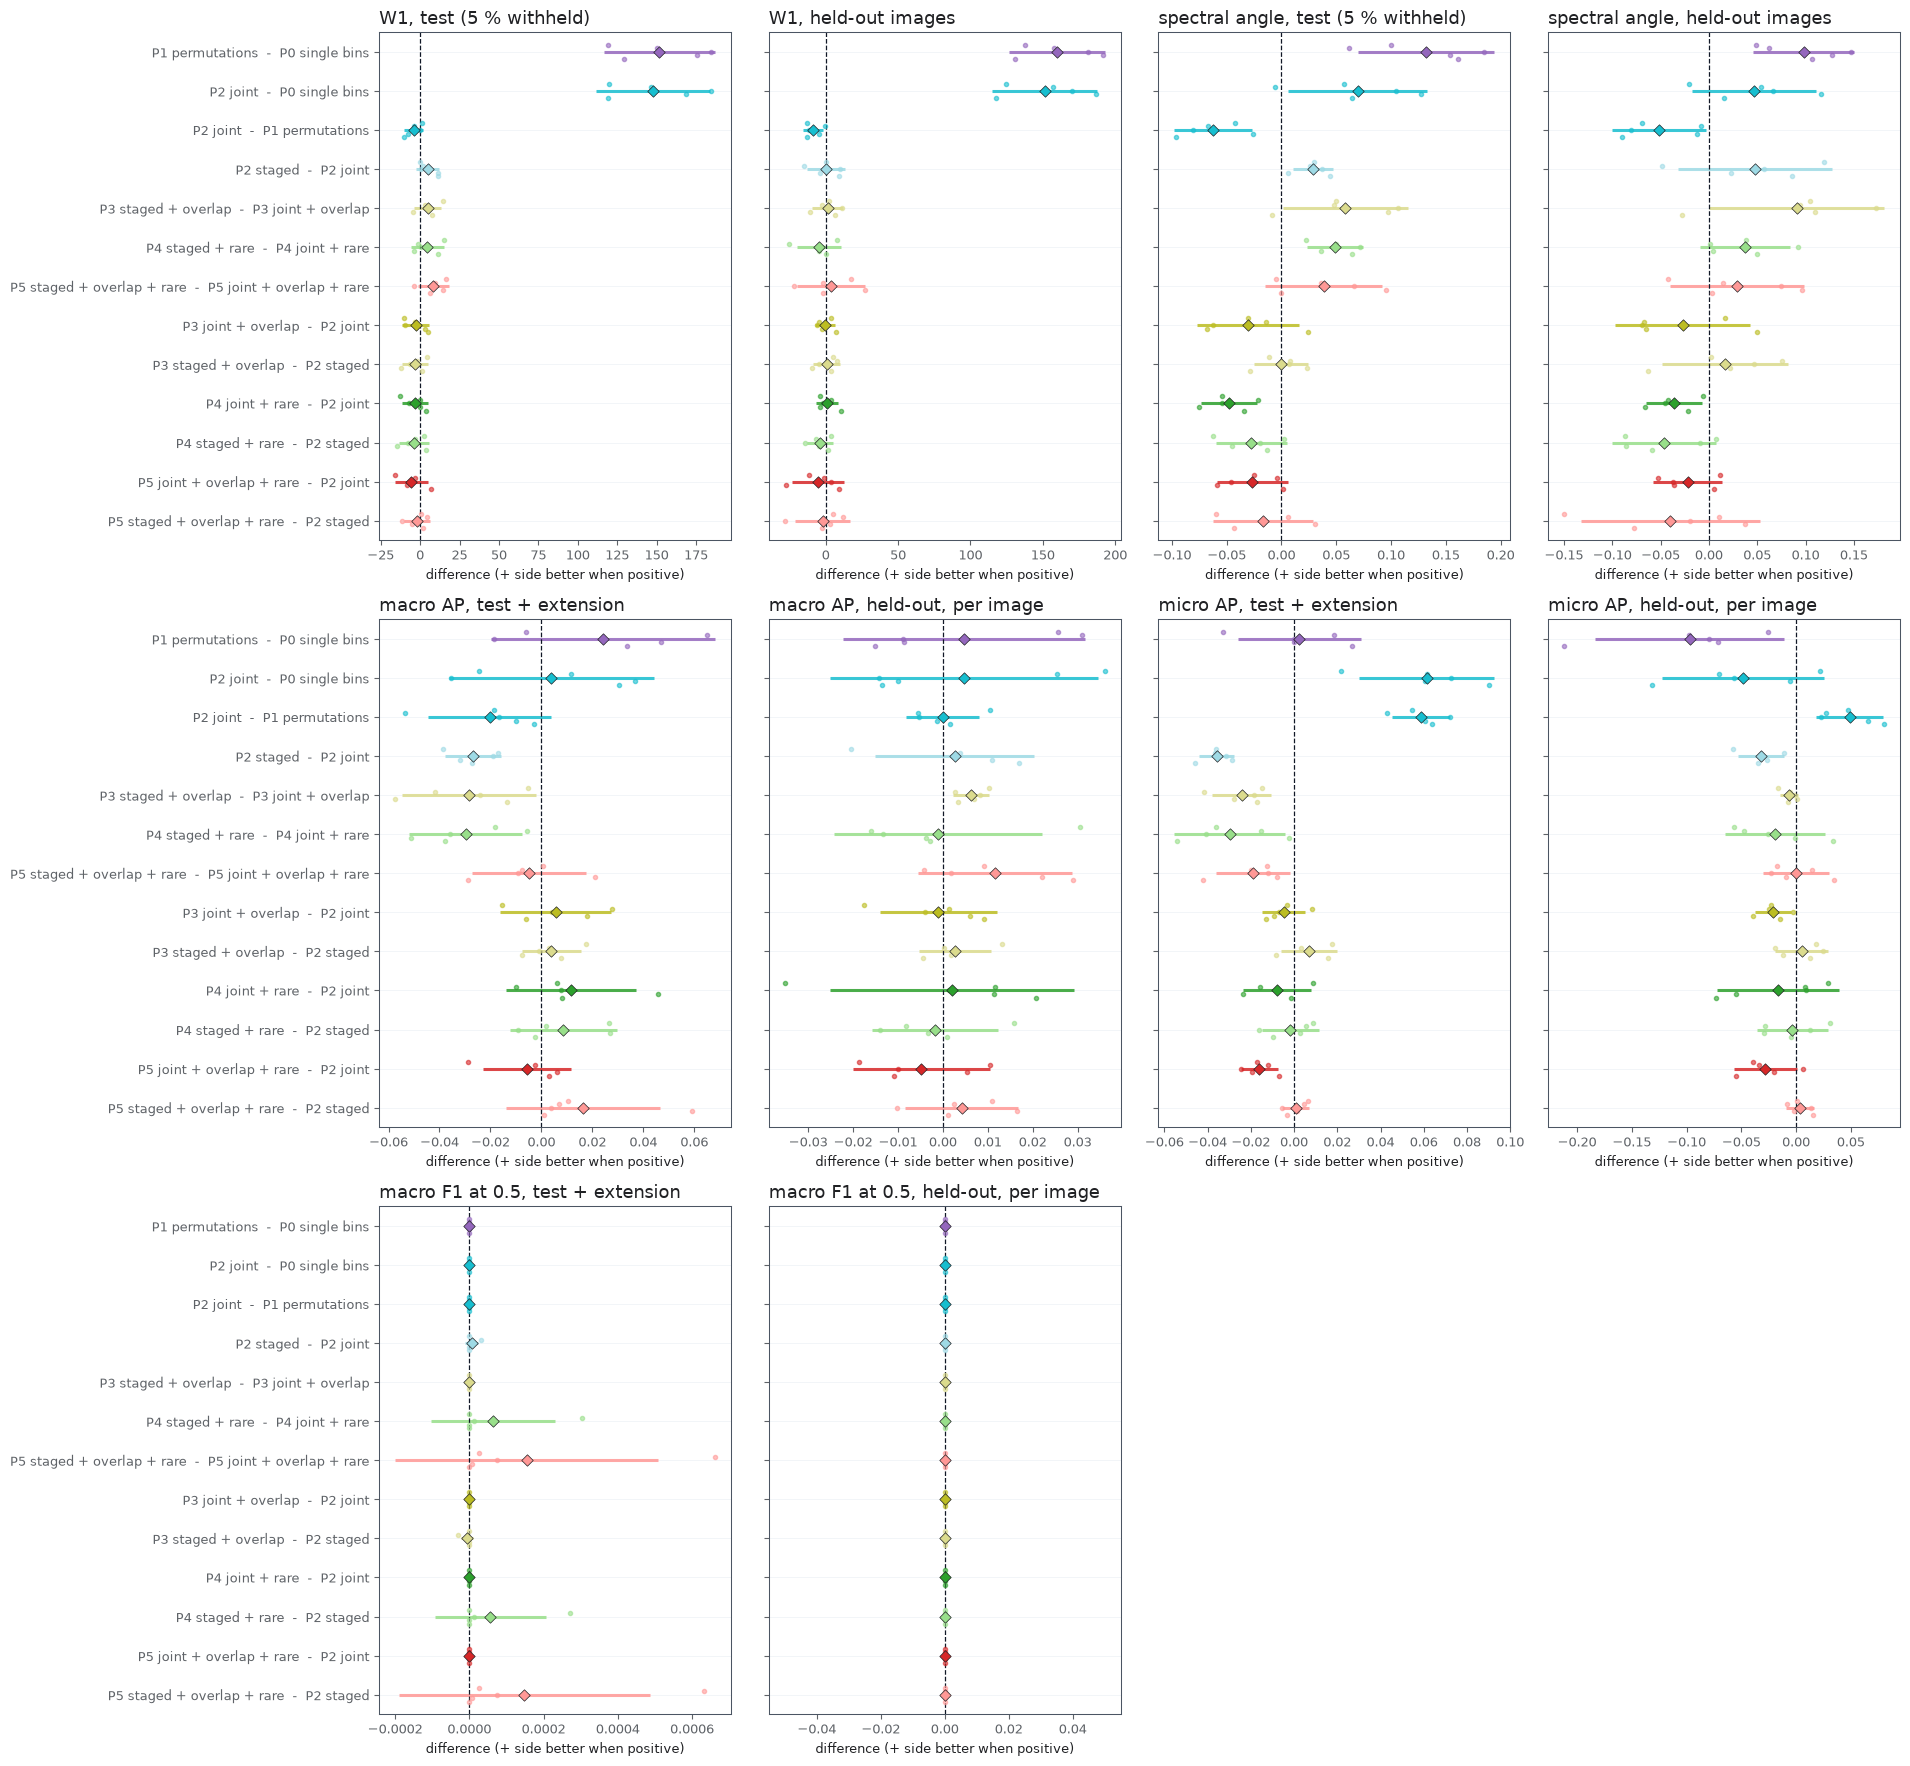

In [6]:
figures.improvement_forest(contrast_summary, panels=key_panels(), variants=CONTRASTS, labels=CONTRAST_LABELS, colors=CONTRAST_COLORS,
                           paired=contrasts, row='contrast', columns=4, xlabel='difference (+ side better when positive)', theme=theme);
rows = contrast_summary[contrast_summary.evaluation.isin(['test', 'test_combined', 'heldout_image_per_image'])]
display(rows.assign(result=interval(rows), column=rows.metric.map(SHORT) + ' | ' + rows.evaluation)
        .pivot_table(index='contrast', columns='column', values='result', aggfunc='first').reindex(CONTRASTS))

### Remarks

- permutation_vs_single: + side better on W1 held-out (160), W1 test (152), spectral angle held-out (0.0982), spectral angle test (0.132); worse on micro AP held-out per image (-0.0972).
- joint_combined_vs_single: + side better on W1 held-out (151), W1 test (148), spectral angle test (0.0695), micro AP test+ext (0.0613); worse on nothing.
- joint_combined_vs_permutation: + side better on micro AP held-out (0.0317), micro AP held-out per image (0.0489), micro AP test+ext (0.0588); worse on W1 held-out (-8.53), spectral angle held-out (-0.0518), spectral angle test (-0.0625).
- staged_vs_joint_base: + side better on spectral angle test (0.0286); worse on macro AP test+ext (-0.0268), micro AP held-out per image (-0.0322), micro AP test+ext (-0.0357).
- staged_vs_joint_overlap: + side better on spectral angle held-out (0.0907), spectral angle test (0.0584), macro AP held-out per image (0.00629); worse on macro AP test+ext (-0.0285), micro AP test+ext (-0.0241).
- staged_vs_joint_rare: + side better on spectral angle test (0.0488); worse on macro AP test+ext (-0.0297), micro AP test+ext (-0.0296).
- staged_vs_joint_all: + side better on macro AP held-out (0.0116); worse on micro AP test+ext (-0.019).
- overlap_quota_joint: + side better on nothing; worse on micro AP held-out per image (-0.0209).
- rare_quota_joint: + side better on nothing; worse on spectral angle held-out (-0.0363), spectral angle test (-0.0478).
- all_quotas_joint: + side better on nothing; worse on micro AP test+ext (-0.016).

### Notes

## Factorial effects of schedule, overlap and rare quota

### Methodology

#### Theoretical

P2-P5 form a $2^3$ design. With factors coded $x \in \{0, 1\}$ (schedule: joint = 0, staged = 1), the main
effect of a factor is the mean over the other factors of (level 1 - level 0), and the two-factor
interaction $A{:}B$ is half the difference of the effect of $A$ between the levels of $B$, both computed per
repetition and sign-adjusted. Schedule is confounded with the synthetic budget (staged = two 10-epoch
phases).

#### Implementation

`factorial` (per repetition) and `factorial_summary`.

#### Figure descriptions

Forest plot: rows = terms (main effects first), panels = key metric x evaluation.

column,W1 | test,macro AP | heldout_image_per_image,macro AP | test,macro AP | test_combined,macro F1 at 0.5 | heldout_image_per_image,macro F1 at 0.5 | test,macro F1 at 0.5 | test_combined,micro AP | heldout_image_per_image,micro AP | test,micro AP | test_combined,spectral angle | test
term,,,,,,,,,,,
schedule,"5.65 [-0.00797, 11.3] (+5/-0)","0.00485 [-0.00313, 0.0128] (+3/-2)","-0.0185 [-0.0272, -0.0099] (+0/-5)","-0.0224 [-0.0299, -0.0149] (+0/-5)","0 [0, 0] (+0/-0)","5.48e-05 [-7.58e-05, 0.000185] (+4/-0)","5.59e-05 [-7.85e-05, 0.00019] (+4/-0)","-0.0145 [-0.0343, 0.00537] (+1/-4)","-0.0311 [-0.0459, -0.0163] (+0/-5)","-0.0271 [-0.0375, -0.0168] (+0/-5)","0.0436 [0.0182, 0.0689] (+5/-0)"
overlap,"-1.56 [-4.83, 1.72] (+1/-4)","0.000203 [-0.00567, 0.00608] (+3/-2)","0.000647 [-0.00478, 0.00607] (+3/-2)","2.45e-06 [-0.0102, 0.0102] (+3/-2)","0 [0, 0] (+0/-0)","2.09e-05 [-2.11e-05, 6.29e-05] (+4/-0)","2.13e-05 [-2.16e-05, 6.42e-05] (+4/-0)","-0.00506 [-0.024, 0.0139] (+3/-2)","-0.000711 [-0.0067, 0.00527] (+2/-3)","-0.000871 [-0.00476, 0.00302] (+2/-3)","0.000305 [-0.0105, 0.0111] (+2/-3)"
rare,"-2.15 [-6.51, 2.22] (+2/-3)","-0.000522 [-0.00788, 0.00684] (+3/-2)","0.00281 [-0.00973, 0.0154] (+3/-2)","0.0053 [-0.014, 0.0246] (+3/-2)","0 [0, 0] (+0/-0)","5.18e-05 [-7.05e-05, 0.000174] (+4/-0)","5.28e-05 [-7.31e-05, 0.000179] (+4/-0)","-0.00716 [-0.0254, 0.0111] (+2/-3)","-0.0103 [-0.0188, -0.00191] (+0/-5)","-0.00676 [-0.0118, -0.00172] (+0/-5)","-0.022 [-0.0384, -0.00558] (+0/-5)"
schedule:overlap,"0.975 [-2.13, 4.08] (+3/-2)","0.00408 [0.00224, 0.00592] (+5/-0)","0.00465 [-0.00316, 0.0125] (+4/-1)","0.00581 [-0.00387, 0.0155] (+4/-1)","0 [0, 0] (+0/-0)","2.09e-05 [-2.11e-05, 6.29e-05] (+4/-0)","2.13e-05 [-2.16e-05, 6.42e-05] (+4/-0)","0.0113 [0.00306, 0.0196] (+5/-0)","0.00636 [-0.00323, 0.016] (+3/-2)","0.00556 [-0.00282, 0.0139] (+3/-2)","0.00484 [-0.0258, 0.0355] (+3/-2)"
schedule:rare,"0.778 [-2.04, 3.6] (+3/-2)","0.000393 [-0.0091, 0.00989] (+3/-2)","0.00404 [-0.00371, 0.0118] (+4/-1)","0.0052 [-0.00561, 0.016] (+3/-2)","0 [0, 0] (+0/-0)","5.18e-05 [-7.05e-05, 0.000174] (+4/-0)","5.28e-05 [-7.31e-05, 0.000179] (+4/-0)","0.00476 [-0.0119, 0.0214] (+3/-2)","0.00426 [-0.00764, 0.0162] (+3/-2)","0.00281 [-0.00763, 0.0133] (+3/-2)","6.36e-05 [-0.0115, 0.0117] (+3/-2)"
overlap:rare,"1.35 [-0.863, 3.56] (+4/-1)","-0.00062 [-0.00693, 0.00569] (+3/-2)","-0.00366 [-0.00853, 0.00121] (+0/-5)","-0.00478 [-0.0111, 0.00153] (+0/-5)","0 [0, 0] (+0/-0)","2.38e-05 [-2.63e-05, 7.4e-05] (+4/-0)","2.44e-05 [-2.69e-05, 7.56e-05] (+4/-0)","0.00286 [-0.0209, 0.0266] (+3/-2)","-0.00177 [-0.0105, 0.007] (+1/-4)","-0.00192 [-0.00889, 0.00505] (+1/-4)","0.0156 [0.000279, 0.031] (+5/-0)"


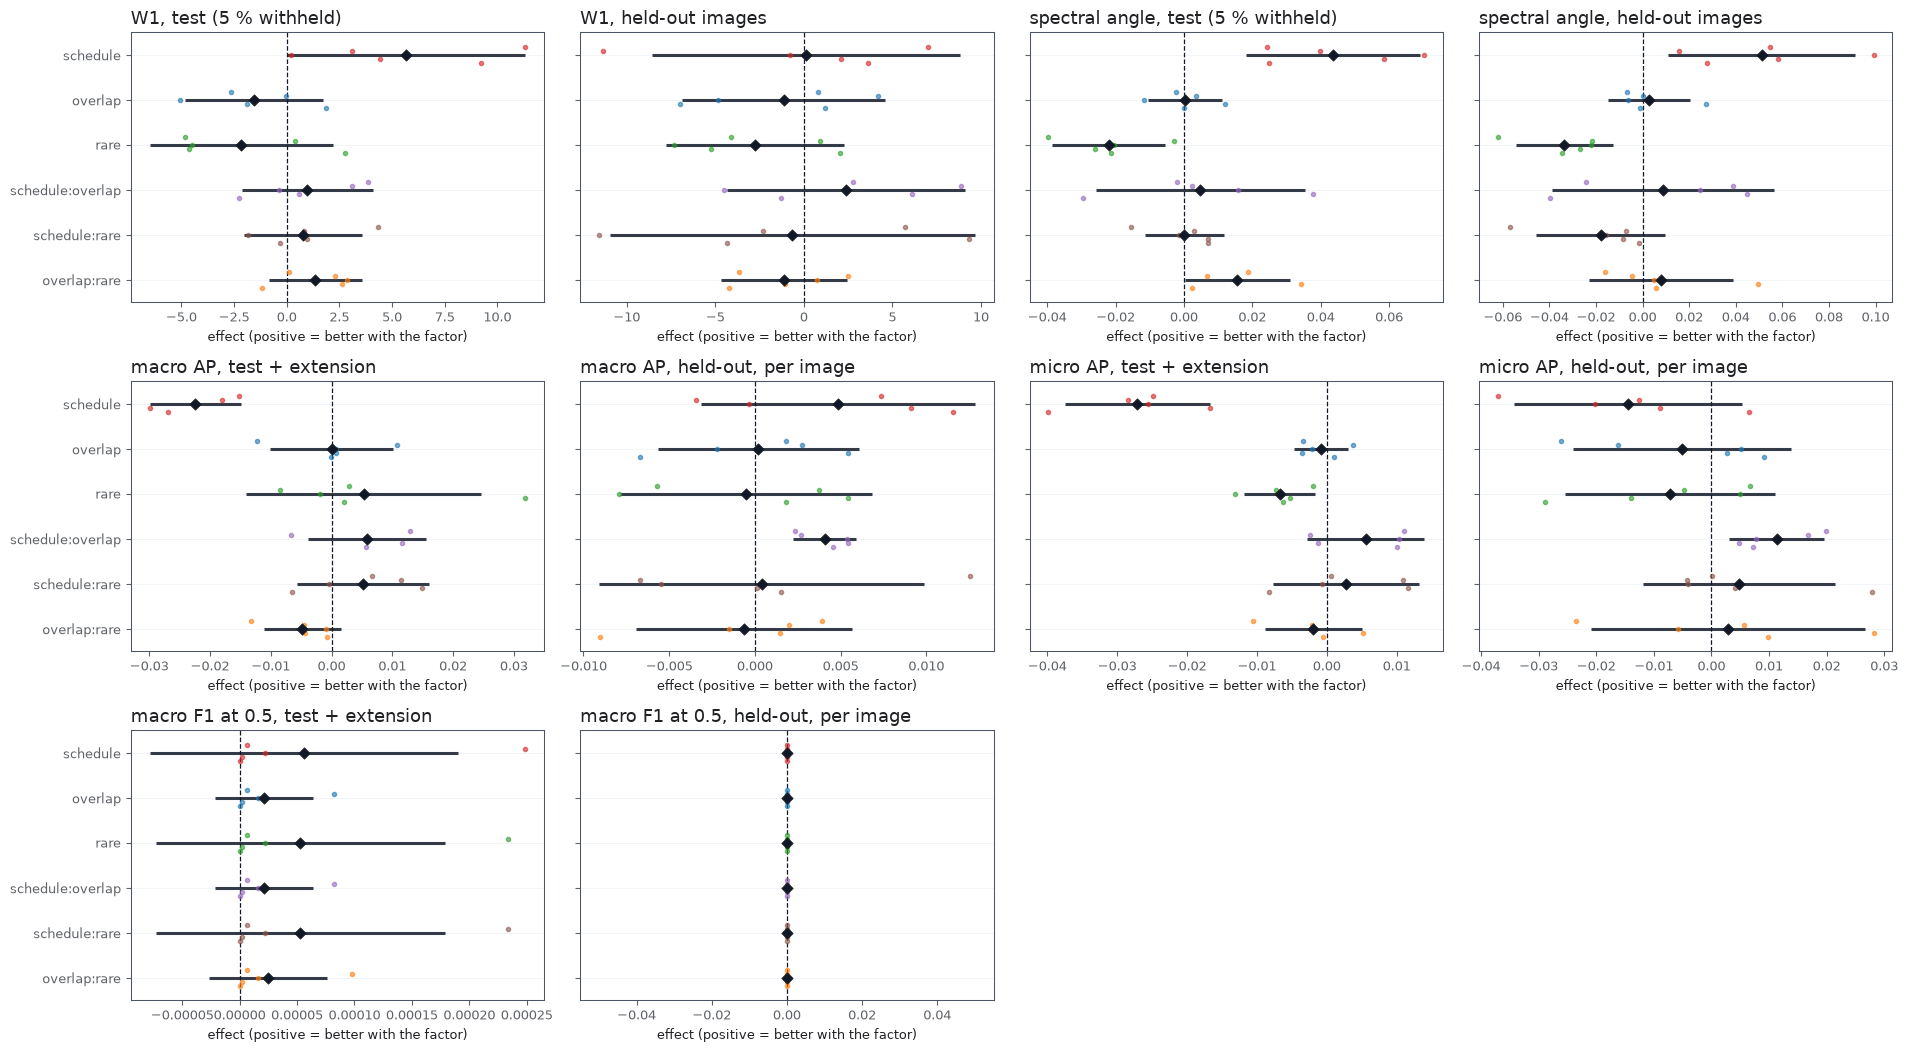

In [7]:
figures.improvement_forest(factorial_summary, panels=key_panels(), variants=TERMS, labels={}, colors={}, paired=factorial, row='term',
                           columns=4, xlabel='effect (positive = better with the factor)', theme=theme);
rows = factorial_summary[factorial_summary.evaluation.isin(['test', 'test_combined', 'heldout_image_per_image'])]
display(rows.assign(result=interval(rows), column=rows.metric.map(SHORT) + ' | ' + rows.evaluation)
        .pivot_table(index='term', columns='column', values='result', aggfunc='first').reindex(TERMS))

### Remarks

- schedule: positive on spectral angle held-out (0.0511), spectral angle test (0.0436); negative on macro AP test+ext (-0.0224), micro AP test+ext (-0.0271).
- rare: positive on nothing; negative on spectral angle held-out (-0.0335), spectral angle test (-0.022), micro AP test+ext (-0.00676).
- schedule:overlap: positive on macro AP held-out per image (0.00408), micro AP held-out (0.00574), micro AP held-out per image (0.0113); negative on nothing.
- schedule:rare: positive on macro AP held-out (0.00565); negative on nothing.
- overlap:rare: positive on spectral angle test (0.0156); negative on nothing.

### Notes

## Results / Summary

### LLM

- **Observed:** permutation_vs_single: + side better on W1 held-out (160), W1 test (152), spectral angle held-out (0.0982), spectral angle test (0.132); worse on micro AP held-out per image (-0.0972).
- **Interpretation:** the clearest construction effect is permutations versus single bins for the reconstruction: models whose synthetic data contain single-bin spectra reconstruct real spectra with a worse spectral angle. The overlap and rare quotas have no consistent effect on the key metrics.

**Absolute levels against the real-only baseline** (means over repetitions; 'better' compares means only, without a test; the intervals are in the improvement sections):

- W1, test: baseline 3.117; others 45.21-197.8; 0 of 10 better than the baseline; best P2 staged (45.21), worst P0 single bins (197.8).
- W1, heldout_image: baseline 3.076; others 25.8-185.6; 0 of 10 better than the baseline; best P1 permutations (25.8), worst P0 single bins (185.6).
- spectral angle, test: baseline 0.9716; others 1.362-1.494; 0 of 10 better than the baseline; best P1 permutations (1.362), worst P0 single bins (1.494).
- spectral angle, heldout_image: baseline 0.8726; others 1.41-1.52; 0 of 10 better than the baseline; best P3 staged + overlap (1.41), worst P0 single bins (1.52).
- macro AP, test_combined: baseline 0.7088; others 0.07253-0.1196; 0 of 10 better than the baseline; best P1 permutations (0.1196), worst P2 staged (0.07253).
- macro AP, heldout_image_per_image: baseline 0.5831; others 0.4626-0.4742; 0 of 10 better than the baseline; best P5 staged + overlap + rare (0.4742), worst P5 joint + overlap + rare (0.4626).
- micro AP, test_combined: baseline 0.8828; others 0.1072-0.1685; 0 of 10 better than the baseline; best P2 joint (0.1685), worst P0 single bins (0.1072).
- micro AP, heldout_image_per_image: baseline 0.8048; others 0.3516-0.4489; 0 of 10 better than the baseline; best P0 single bins (0.4489), worst P1 permutations (0.3516).
- macro F1 at 0.5, test_combined: baseline 0.4908; others 0-0.0001544; 0 of 10 better than the baseline; best P5 staged + overlap + rare (0.0001544), worst P0 single bins (0).
- macro F1 at 0.5, heldout_image_per_image: baseline 0.1753; others 0-0; 0 of 10 better than the baseline; best P0 single bins (0), worst P0 single bins (0).

### Person